In [1]:
## Include the packages and samplers
using Distributions
using Random
using LinearAlgebra
using StatsBase
using Base.Threads
using JLD2
using CSV
using DataFrames
include("../../src/pdmps/PDMP_discrete.jl")
include("../../src/coupled_estimator_verb.jl")

rhee_glynn

In [2]:
## Generate data, gradient and potential function
csv_file_path = "small_logit_data.csv"

# Load the CSV file into a DataFrame
data = CSV.File(csv_file_path) |> DataFrame
Y = Vector(data[:,:y])
X = Matrix(data[:, 1:(end-1)])

p = size(X)[2]
prior_precision = ones(p)

# Potential 
function U(x::Vector)
    μ = X*x
    η_val = exp.(μ)
    return (sum(log.(1.0 .+ η_val) -Y .* μ) +  x' * (prior_precision .* x)/2.0)
end
# Grad 
function ∇U(x::Vector)
    μ = X*x
    η_val = exp.(μ)
    prior_terms = prior_precision .* x 
    ϕ = X .* (η_val ./(1 .+ η_val) .- Y)
    grad = sum(ϕ, dims=1)[1,:] + prior_terms
    return grad
end
# Hessian of the potential
function Hess(x)
    μ = X*x
    η_val = exp.(μ)
    sum_term = sum(X[i,:] * X[i,:]' * η_val[i] / (1.0 + η_val[i])^2 for i in 1:length(η_val))
    diagm(fill(1., p)) .* prior_precision + Symmetric(sum_term, :U)
end
H_bound = (X' * X)/4 + diagm(fill(1., p)).*prior_precision;

using Optim

∇U! = function(storage, x)
    storage[:] = ∇U(x)
end

res = Optim.optimize(U, ∇U!, randn(p), LBFGS(), Optim.Options(g_tol = 1e-15, show_trace = false))
x_mode = Optim.minimizer(res)

Σinv = Hess(x_mode) 
Σ = inv(factorize(Σinv))
Σinv = inv(Σ); 


In [3]:
function mn(x)
    U(x), x, x.^2
end
p = size(X)[2]
# #sampler = BPS_coupling(∇U, H_bound, 4.0, 8, 2.0, mn)
# sampler = BOOM_coupling(∇U, H_bound - Σinv, Σ, x_mode, 4.0, 8, 2.0, mn)
# discrete_sampler = DiscretePDMPCoupling(sampler)

# x1 = randn(p); x2 = randn(p)
# coupled_state = discrete_sampler.init(x1, x2)

# (kern, (est1, est2, est3), _, cs) = rhee_glynn(discrete_sampler.kernel, coupled_state, 75, 750)


16

In [4]:
function get_coupling!(est1_out,est2_out,est3_out, comp_out, discrete_sampler)
    x1 = randn(p); x2 = randn(p)
    coupled_state = discrete_sampler.init(x1, x2)
    i = 1
    while true
        coupled_state = discrete_sampler.kernel(coupled_state)
        i = i + 1
        if coupled_state.coupled
            break
        end
    end
    niter_burn = ceil(max(1000.0 - coupled_state.state_1.z[1], 1.0)/discrete_sampler.kernel.Δt)
    for k in 1:niter_burn
        coupled_state = discrete_sampler.kernel(coupled_state)
    end
    cs = coupled_state.coupled_status
    num_grad = cs.num_grad_1+cs.num_grad_coupled

    niter = ceil(1000.0/discrete_sampler.kernel.Δt)
    h = coupled_state.state_1.h
    for k in 1:niter
        coupled_state = discrete_sampler.kernel(coupled_state)
        h = h .+ coupled_state.state_1.h
    end
    h = h ./ niter

    est1_out .= h[1]
    est2_out .= h[2]
    est3_out .= h[3]

    cs = coupled_state.coupled_status
    comp_out .= [i, cs.num_grad_1+cs.num_grad_2, cs.num_grad_1+cs.num_grad_coupled - num_grad, cs.stoch_time]
    return Nothing
end

get_coupling! (generic function with 1 method)

In [23]:
Random.seed!(0)
dt_values = [1., 2., 4., 8]
l_values = [0.5, 1, 2, 3., 4.]

var_h1 = zeros(Float64, length(dt_values), length(l_values))
var_h21 = zeros(Float64, length(dt_values), length(l_values))
var_h2 = zeros(Float64, length(dt_values), length(l_values))
var_h3 = zeros(Float64, length(dt_values), length(l_values))
Kern = zeros(Float64, length(dt_values), length(l_values))
Kern95 = zeros(Float64, length(dt_values), length(l_values))
nGradCouple = zeros(Float64, length(dt_values), length(l_values))
nGradTotal = zeros(Float64, length(dt_values), length(l_values))
stochtCouple = zeros(Float64, length(dt_values), length(l_values))
stochtCouple95 = zeros(Float64, length(dt_values), length(l_values))
n_tune_reps = 100
check = zeros(Float64, length(dt_values), length(l_values))

for (l_index, l) in enumerate(l_values)
    for (dt_index, dt) in enumerate(dt_values)
                
        # sampler = BOOM_coupling(∇U, H_bound, dt, Int(dt*10), l, mn)
        sampler = BOOM_coupling(∇U, H_bound - Σinv, Σ, x_mode, dt, Int(dt*10), l, mn)
        discrete_sampler = DiscretePDMPCoupling(sampler)

        # Repeat and store grad events
        print("\ndt=",dt,"\n")
        h1s = zeros(Float64, n_tune_reps)
        h2s = zeros(Float64, n_tune_reps, p)
        h3s = zeros(Float64, n_tune_reps, p)
        comp = zeros(Float64, n_tune_reps, 4)

        a = zeros(Float64, n_tune_reps)
        Threads.@threads for l in 1:n_tune_reps
            a[l] = rand()
            get_coupling!(view(h1s, l),view(h2s, l, :),view(h3s, l, :), view(comp, l, :),
            discrete_sampler)
        end
        check[dt_index, l_index] = length(unique(a))
        var_h1[dt_index, l_index] = var(h1s)
        var_h21[dt_index, l_index] = var(h2s[:,1])
        var_h2[dt_index, l_index] = sum(var(h2s, dims = 1))
        var_h3[dt_index, l_index] = sum(var(h3s, dims = 1))
        Kern[dt_index, l_index] = mean(comp[:,1])
        Kern95[dt_index, l_index] = StatsBase.quantile(comp[:,1], 0.95)
        print(comp[:,1])
        nGradCouple[dt_index, l_index] = mean(comp[:,2])
        nGradTotal[dt_index, l_index] = mean(comp[:,3])
        stochtCouple[dt_index, l_index] = mean(comp[:,4])
        stochtCouple95[dt_index, l_index] = StatsBase.quantile(comp[:,4], 0.95)
    end
    print("\n \n",nGradTotal .* (var_h2 + var_h3)," \n", check[:, l_index])
end


matrices_dict_tuning = Dict("var_h1" => var_h1, "var_h2" => var_h2, "var_h21" => var_h21, "var_h3" => var_h3, "stochtCouple95" => stochtCouple95, 
                        "Kern" => Kern,"Kern95" => Kern95, "nGradCouple" => nGradCouple, "nGradTotal" => nGradTotal, 
                        "dt_values" => dt_values, "l_values" => l_values, "stochtCouple" => stochtCouple)
@save "BOOM_tuning.jld2" matrices_dict_tuning

print(check)


dt=1.0
[203.0, 161.0, 264.0, 61.0, 48.0, 433.0, 215.0, 218.0, 120.0, 306.0, 871.0, 1347.0, 1115.0, 90.0, 822.0, 533.0, 181.0, 112.0, 534.0, 233.0, 34.0, 603.0, 58.0, 206.0, 259.0, 451.0, 666.0, 1244.0, 142.0, 252.0, 606.0, 471.0, 445.0, 1374.0, 154.0, 300.0, 139.0, 443.0, 171.0, 314.0, 256.0, 35.0, 365.0, 46.0, 1339.0, 1126.0, 1392.0, 304.0, 185.0, 290.0, 69.0, 356.0, 322.0, 53.0, 1260.0, 469.0, 370.0, 775.0, 488.0, 171.0, 654.0, 899.0, 440.0, 558.0, 746.0, 212.0, 618.0, 524.0, 635.0, 406.0, 386.0, 186.0, 304.0, 203.0, 60.0, 89.0, 65.0, 467.0, 150.0, 248.0, 244.0, 909.0, 662.0, 191.0, 1367.0, 713.0, 699.0, 637.0, 699.0, 834.0, 194.0, 523.0, 872.0, 315.0, 165.0, 210.0, 92.0, 181.0, 152.0, 124.0]
dt=2.0
[24.0, 266.0, 382.0, 248.0, 490.0, 131.0, 123.0, 415.0, 212.0, 138.0, 291.0, 166.0, 225.0, 336.0, 207.0, 75.0, 62.0, 124.0, 194.0, 430.0, 476.0, 430.0, 258.0, 323.0, 68.0, 88.0, 21.0, 253.0, 271.0, 86.0, 337.0, 243.0, 257.0, 217.0, 289.0, 363.0, 149.0, 554.0, 410.0, 177.0, 470.0, 507.0, 

In [6]:
function assign_to_global(dict::Dict{String, Array{Float64}})
    for (key, value) in dict
        @eval global $(Symbol(key)) = $(value)
    end
end

assign_to_global (generic function with 1 method)

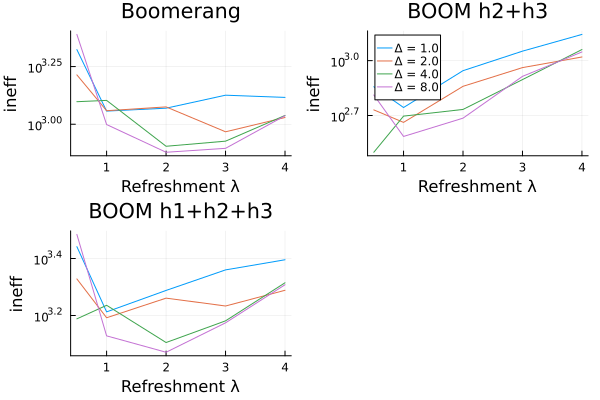

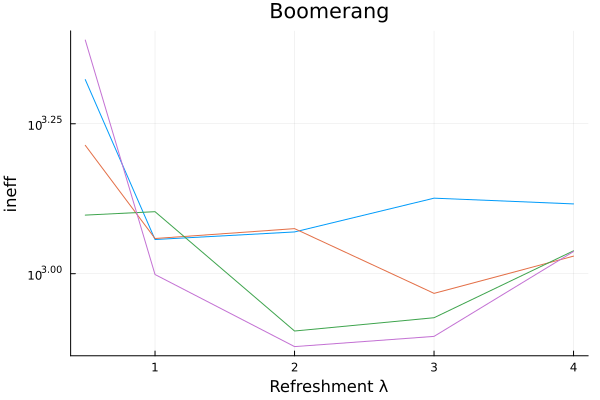

4×5 Matrix{Float64}:
 1263.07   443.98   115.249   79.2525  62.1174
 1060.21   555.844   99.6683  64.0326  60.8273
  895.311  355.785  128.378   62.4614  70.5583
 1036.84   465.54    90.9394  74.14    76.4648

In [26]:
using Plots
using JLD2
@load "BOOM_tuning.jld2"
assign_to_global(matrices_dict_tuning)

res_ineff = nGradTotal .* (var_h1 + var_h2)
p_12 = Plots.plot(l_values, res_ineff[1,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10, legend = false,
    label ="Δ = $(dt_values[1])", title = "Boomerang")

for i in 2:length(dt_values)
    Plots.plot!(l_values, res_ineff[i,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10,
    label ="Δ = $(dt_values[i])")
end
res_ineff = nGradTotal  .* (var_h3 + var_h2)
p_32 = Plots.plot(l_values, res_ineff[1,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10,
    label ="Δ = $(dt_values[1])", title = "BOOM h2+h3")

for i in 2:length(dt_values)
    Plots.plot!(l_values, res_ineff[i,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10,
    label ="Δ = $(dt_values[i])")
end

res_ineff = nGradTotal  .* (var_h3 + var_h2+ var_h1)
p_a = Plots.plot(l_values, res_ineff[1,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10,
    label ="Δ = $(dt_values[1])", title = "BOOM h1+h2+h3")

for i in 2:length(dt_values)
    Plots.plot!(l_values, res_ineff[i,:] |> Vector,
    xlabel="Refreshment λ", ylabel="ineff", yscale = :log10,
    label ="Δ = $(dt_values[i])",legend=false)
end

display(plot(p_12, p_32, p_a))
display(plot(p_12))
nGradTotal .* (var_h1 + var_h2)
stochtCouple95

In [12]:
function get_estimate!(est1_out,est2_out,est3_out, comp_out, discrete_sampler, K, M)
    x1 = randn(p); x2 = randn(p)
    coupled_state = discrete_sampler.init(x1, x2)
    
    (kern, (est1, est2, est3), _, cs) = rhee_glynn(discrete_sampler.kernel, coupled_state, K, M)

    est1_out .= est1
    est2_out .= est2
    est3_out .= est3

    comp_out .= [kern, cs.num_grad_1, cs.num_grad_2, cs.num_grad_coupled]
    return Nothing
end

get_estimate! (generic function with 1 method)

In [15]:
Random.seed!(0)
sim_runs = 1:1000
K = 10
M_vals = [K, 50*K, 100*K]

comp = Array{Float64}(undef, length(sim_runs), 4, 3) # kernel, grad
h_1 = Array{Float64}(undef, length(sim_runs), 3)
h_2 = Array{Float64}(undef, length(sim_runs), p, 3)
h_3 = Array{Float64}(undef, length(sim_runs), p, 3)

Δt = 8.0
λᵣ = 3.0
ΔM = 80
sampler = BOOM_coupling(∇U, H_bound - Σinv, Σ, x_mode, Δt, ΔM, λᵣ, mn)
discrete_sampler = DiscretePDMPCoupling(sampler)

for (m_ind, m) in enumerate(M_vals)
    println("At m=",m)
    Threads.@threads for l in sim_runs
        get_estimate!(view(h_1, l, m_ind), view(h_2, l, :, m_ind), view(h_3, l, :,m_ind), 
                view(comp, l, :, m_ind), discrete_sampler, K, m)
    end
    matrices_dict = Dict("h_1" => h_1, "h_2" => h_2, "h_3" => h_3, "M_vals" => M_vals,
                        "comp" => comp, "tuning" => [Δt, ΔM, λᵣ, K])
    
    @save "BOOM_K$(K)_l$(λᵣ)_t$(Δt).jld2" matrices_dict
end


At m=10
At m=500
At m=1000


In [29]:
function assign_to_global(dict::Dict{String, Array})
    for (key, value) in dict
        @eval global $(Symbol(key)) = $(value)
    end
end
@load "BOOM_K10_l3.0_t8.0.jld2"
K = 10
assign_to_global(matrices_dict)
print(keys(matrices_dict))
print(M_vals)

comp_K = 2 * (comp[:,1,1] .- 1) + max.(1,M_vals[1]+1 .-comp[:,1,1])
comp_10K = 2 * (comp[:,1,2] .- 1) + max.(1,M_vals[2]+1 .-comp[:,1,2])
comp_20K = 2 * (comp[:,1,3] .- 1) + max.(1,M_vals[3]+1 .-comp[:,1,3])

println("COMP")
println(mean(comp_K)," ", mean(comp_10K)," ", mean(comp_20K))
println("\n VARIANCE")
println(sum(var(h_1[:,1],dims =1)) + sum(var(h_2[:,:,1],dims =1)))
println(sum(var(h_1[:,2],dims =1)) + sum(var(h_2[:,:,2],dims =1)))
println(sum(var(h_1[:,3],dims =1)) + sum(var(h_2[:,:,3],dims =1)))

print(quantile(comp[:,1,1], 0.95))
print("\nngrad:",mean(comp[:,4,1] + comp[:,2,1]+ comp[:,3,1]))
print("\nngrad:",mean(comp[:,4,2] + comp[:,2,2]+ comp[:,3,2]))
print("\nngrad:",mean(comp[:,4,3] + comp[:,2,3]+ comp[:,3,3]))

["M_vals", "tuning", "h_3", "h_1", "h_2", "comp"][10, 500, 1000]COMP
13.147 502.965 1002.911

 VARIANCE
445.3413583342904
0.7962350556392973
0.014978657320943042
10.0
ngrad:1361.373
ngrad:41826.299
ngrad:83147.619

In [18]:
function non_coupled_estimator!(est1_out,est2_out,est3_out, comp_stored, comp_budget, discrete_sampler)
    x1 = randn(p); x2 = randn(p)
    coupled_state = discrete_sampler.init(x1, x2)
    
    niter_burn = ceil(1000.0/discrete_sampler.kernel.Δt)
    for k in 1:niter_burn
        coupled_state = discrete_sampler.kernel(coupled_state)
    end
    cs = coupled_state.coupled_status
    num_grad = cs.num_grad_1+cs.num_grad_coupled

    h = coupled_state.state_1.h
    for k in 1:comp_budget
        coupled_state = discrete_sampler.kernel(coupled_state)
        h = h .+ coupled_state.state_1.h
    end
    h = h ./ comp_budget
    cs = coupled_state.coupled_status
    comp_stored .= cs.num_grad_1 + cs.num_grad_coupled - num_grad

    est1_out .= h[1]
    est2_out .= h[2]
    est3_out .= h[3]
    return Nothing
end

non_coupled_estimator! (generic function with 1 method)

In [19]:
Random.seed!(0)
# Run BPS sampler for same compute
Δt = 8.0
λᵣ = 3.0
ΔM = 80
sampler = BOOM_coupling(∇U, H_bound - Σinv, Σ, x_mode, Δt, ΔM, λᵣ, mn)
discrete_sampler = DiscretePDMPCoupling(sampler)

sim_runs = 1:1000
refh_1 = Array{Float64}(undef, length(sim_runs), 3)
refh_2 = Array{Float64}(undef, length(sim_runs), p, 3)
refh_3 = Array{Float64}(undef, length(sim_runs), p, 3)
refcomp = Array{Float64}(undef, length(sim_runs), 3)

println("comp 1")
compute_budget = ceil(mean(comp_K))
Threads.@threads for l in sim_runs
    non_coupled_estimator!(view(refh_1, l, 1), view(refh_2, l, :, 1), view(refh_3, l, :,1), view(refcomp, l, 1),
            compute_budget, discrete_sampler)
end

println("comp 2")
compute_budget = ceil(mean(comp_10K))
Threads.@threads for l in sim_runs
    non_coupled_estimator!(view(refh_1, l, 2), view(refh_2, l, :, 2), view(refh_3, l, :,2), view(refcomp, l, 2),
            compute_budget, discrete_sampler)
end

println("comp 3")
compute_budget = floor(mean(comp_20K))
Threads.@threads for l in sim_runs
    non_coupled_estimator!(view(refh_1, l, 3), view(refh_2, l, :, 3), view(refh_3, l, :,3), view(refcomp, l, 3),
            compute_budget, discrete_sampler)
end

matrices_dict_ref = Dict("refh_1" => refh_1, "refh_2" => refh_2, "refh_3" => refh_3, "refcomp" => refcomp,
                        "BOOMParam" => [Δt, λᵣ, K], "comp" => comp)
@save "BOOM_ref.jld2" matrices_dict_ref

comp 1
comp 2
comp 3


In [32]:
Ineff1 = mean(comp[:,4,1] + comp[:,2,1]+ comp[:,3,1])*(sum(var(h_1[:,1],dims =1)) + sum(var(h_2[:,:,1],dims =1))) / ( mean(refcomp[:,1]) * (sum(var(refh_1[:,1],dims =1))+sum(var(refh_2[:,:,1],dims =1))))
Ineff2 = mean(comp[:,4,2] + comp[:,2,2]+ comp[:,3,2])*(sum(var(h_1[:,2],dims =1)) + sum(var(h_2[:,:,2],dims =1))) / ( mean(refcomp[:,2]) * (sum(var(refh_1[:,2],dims =1))+sum(var(refh_2[:,:,2],dims =1))))
Ineff3 = mean(comp[:,4,3] + comp[:,2,3]+ comp[:,3,3])*(sum(var(h_1[:,3],dims =1)) + sum(var(h_2[:,:,3],dims =1))) / ( mean(refcomp[:,3]) * (sum(var(refh_1[:,3],dims =1))+sum(var(refh_2[:,:,3],dims =1))))
println(Ineff1)
println(Ineff2)
println(Ineff3)
print(mean(refcomp[:,1])," ",mean(refcomp[:,2])," ",mean(refcomp[:,3]))

619.6076619034314
37.663922568506784
1.352376046520914
1156.174 41544.485 82787.175

In [20]:
println("\n VARIANCE (refrence)")
println(sum(var(refh_1[:,1],dims =1))," ",sum(var(refh_2[:,:,1],dims =1))," ",sum(var(refh_3[:,:,1],dims =1)))
println(sum(var(refh_1[:,2],dims =1))," ",sum(var(refh_2[:,:,2],dims =1))," ",sum(var(refh_3[:,:,2],dims =1)))
println(sum(var(refh_1[:,3],dims =1))," ",sum(var(refh_2[:,:,3],dims =1))," ",sum(var(refh_3[:,:,3],dims =1)))


 VARIANCE (refrence)
0.7433044614545465 0.10300692540757422 0.5971676726921366
0.01850249355195608 0.0027814355692163495 0.016457017561498886
0.00969378466300453 0.001430245800465847 0.008463866889157349


In [21]:
println("\n Ineff ")
println(sum(var(h_1[:,1],dims =1))/sum(var(refh_1[:,1],dims =1))," ",sum(var(h_2[:,:,1],dims =1))/sum(var(refh_2[:,:,1],dims =1))," ",sum(var(h_3[:,:,1],dims =1))/sum(var(refh_3[:,:,1],dims =1)))
println(sum(var(h_1[:,2],dims =1))/sum(var(refh_1[:,2],dims =1))," ",sum(var(h_2[:,:,2],dims =1))/sum(var(refh_2[:,:,2],dims =1))," ",sum(var(h_3[:,:,2],dims =1))/sum(var(refh_3[:,:,2],dims =1)))
println(sum(var(h_1[:,3],dims =1))/sum(var(refh_1[:,3],dims =1))," ",sum(var(h_2[:,:,3],dims =1))/sum(var(refh_2[:,:,3],dims =1))," ",sum(var(h_3[:,:,3],dims =1))/sum(var(refh_3[:,:,3],dims =1)))

println("\n Ineff h = h1 + h2")
println((sum(var(h_1[:,1],dims =1)) + sum(var(h_2[:,:,1],dims =1)))/(sum(var(refh_1[:,1],dims =1))+sum(var(refh_2[:,:,1],dims =1))))
println((sum(var(h_1[:,2],dims =1)) + sum(var(h_2[:,:,2],dims =1)))/(sum(var(refh_1[:,2],dims =1))+sum(var(refh_2[:,:,2],dims =1))))
println((sum(var(h_1[:,3],dims =1)) + sum(var(h_2[:,:,3],dims =1)))/(sum(var(refh_1[:,3],dims =1))+sum(var(refh_2[:,:,3],dims =1))))

println("\n Ineff h = h2 + h3")
println((sum(var(h_3[:,:,1],dims =1)) + sum(var(h_2[:,:,1],dims =1)))/(sum(var(refh_3[:,:,1],dims =1))+sum(var(refh_2[:,:,1],dims =1))))
println((sum(var(h_3[:,:,2],dims =1)) + sum(var(h_2[:,:,2],dims =1)))/(sum(var(refh_3[:,:,2],dims =1))+sum(var(refh_2[:,:,2],dims =1))))
println((sum(var(h_3[:,:,3],dims =1)) + sum(var(h_2[:,:,3],dims =1)))/(sum(var(refh_3[:,:,3],dims =1))+sum(var(refh_2[:,:,3],dims =1))))



 Ineff 
588.9188234736748 73.73649278135773 151.9987123071612
42.1614714807218 5.803730133073017 13.448432512885526
1.3904086846229229 1.0490049599505022 1.090122975998257

 Ineff h = h1 + h2
526.214541417773
37.410153506254325
1.3465135114588793

 Ineff h = h2 + h3
140.4850832340631
12.343185278567324
1.0841791514613213


In [59]:
# function get_samples(budget, burn, discrete_sampler)
#     x1 = randn(p); x2 = randn(p)
#     coupled_state = discrete_sampler.init(x1, x2)
    
#     for k in 1:burn
#         coupled_state = discrete_sampler.kernel(coupled_state)
#     end
#     h1 = zeros(budget, 1)
#     h2 = zeros(budget, p)
#     h3 = zeros(budget, p)

#     for k in 1:budget
#         coupled_state = discrete_sampler.kernel(coupled_state)
#         h1[k], h2[k,:], h3[k,:] = coupled_state.state_1.h
#     end

#     return h1, h2, h3
# end

# res = get_samples(1000,1000,discrete_sampler)


([39.232807501213436; 40.754148822567714; … ; 38.42125112271732; 37.96191211476084;;], [-0.1287953581195332 0.006492113816763502 … 0.9181160365569379 -0.9340253783295304; -0.12936088099593498 -0.22823022588861303 … 1.0453043582172903 -1.050854098377913; … ; -0.19214144116982557 -0.04666665762639444 … 0.8516573605858263 -0.9657296313452685; -0.12550301019292237 0.28033095862747504 … 1.1598456409015325 -1.0008651376502946], [0.12053026140730425 0.12100101694049743 … 0.9371186475581611 1.0479915462643286; 0.09981068303596183 0.17891875061741622 … 1.2030975594100755 1.301155438142935; … ; 0.10398292851366825 0.09514819379631255 … 0.7908847483986291 1.1412315290079573; 0.10812414673010143 0.12519815724878275 … 1.4337325641550096 1.0651713593275332])

In [62]:
# using CSV
# CSV.write("h2.csv",DataFrame(res[2], :auto)) 
# CSV.write("h3.csv",DataFrame(res[3], :auto)) 

"h3.csv"